In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder


# TODO: Define your paths to the features folder and the models folder
# HINT: Use os.path.join to stay cross-platform compatible
FEAT_DIR = os.path.join(os.getcwd(),'features')
os.makedirs(FEAT_DIR,exist_ok=True)
MODEL_DIR = os.path.join(os.getcwd(),'models')
os.makedirs(MODEL_DIR,exist_ok=True)


FEAT_CSV = os.path.join(FEAT_DIR,'statistical_features.csv')
XGB_MODEL_PATH = os.path.join(MODEL_DIR, 'specialist_xgboost.joblib')

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# TODO: Load the CSV from the path defined above
# HINT: Use df.head() to verify the columns loaded correctly.
df = pd.read_csv(FEAT_CSV)
print(df.head())

# TODO: Separate features (X) and target (y)
# HINT: Drop 'label' and 'filename' from X. y should only be the 'label' column.
feature_columns = ['centroid_mean', 'centroid_var','chroma_mean','chroma_var','rms_mean', 'rms_var']
X = df[feature_columns]

y = df['label']



# TODO: Encode the genre strings into integers (0-9)
# HINT: XGBoost will crash if you give it strings like "rock".
# Use encoder.fit_transform(y).
print(y)

# TODO: Split into train/test (80/20)
# HINT: Use stratify=y to ensure each genre is equally represented in 
# your test set—this is critical for small datasets like GTZAN!
X_train, X_test, y_train,y_test = train_test_split(X,y ,
                          train_size=0.8,
                          stratify=y,
                          random_state=42)

   centroid_mean   centroid_var  chroma_mean  chroma_var  rms_mean   rms_var  \
0    1773.358004  169450.829707     0.335555    0.090997  0.130189  0.003559   
1    1817.244034   90766.297514     0.343523    0.086782  0.112119  0.001491   
2    1790.722358  110071.206762     0.347746    0.092495  0.130895  0.004552   
3    1660.545231  109496.936309     0.363863    0.087207  0.131349  0.002338   
4    1634.465076   77425.419156     0.335481    0.088482  0.142370  0.001734   

   label  
0      0  
1      0  
2      0  
3      0  
4      0  
0       0
1       0
2       0
3       0
4       0
       ..
9976    9
9977    9
9978    9
9979    9
9980    9
Name: label, Length: 9981, dtype: int64


In [12]:
from xgboost import XGBClassifier

# TODO: Initialize the XGBClassifier
# HINT: For a cluster, if you have a GPU, set tree_method='gpu_hist'.
# Otherwise, use tree_method='hist' for faster CPU training.
# Initialize the model
model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',  # Use 'gpu_hist' if GPU available
    random_state=42,
    eval_metric='mlogloss'
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)
# TODO: Train (Fit) the model
# HINT: Use eval_set=[(X_test, y_test)] to track how the model 
# learns over time in the output logs.
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

genre_names = np.load(os.path.join(FEAT_DIR,'label_names.npy'))
print(genre_names)


[0]	validation_0-mlogloss:2.15126
[1]	validation_0-mlogloss:2.03895
[2]	validation_0-mlogloss:1.94794
[3]	validation_0-mlogloss:1.87211
[4]	validation_0-mlogloss:1.80677
[5]	validation_0-mlogloss:1.74895
[6]	validation_0-mlogloss:1.69795
[7]	validation_0-mlogloss:1.65370
[8]	validation_0-mlogloss:1.61301
[9]	validation_0-mlogloss:1.57799
[10]	validation_0-mlogloss:1.54578
[11]	validation_0-mlogloss:1.51744
[12]	validation_0-mlogloss:1.49217
[13]	validation_0-mlogloss:1.46952
[14]	validation_0-mlogloss:1.44760
[15]	validation_0-mlogloss:1.42688
[16]	validation_0-mlogloss:1.40745
[17]	validation_0-mlogloss:1.38941
[18]	validation_0-mlogloss:1.37327
[19]	validation_0-mlogloss:1.35781
[20]	validation_0-mlogloss:1.34372
[21]	validation_0-mlogloss:1.33175
[22]	validation_0-mlogloss:1.32009
[23]	validation_0-mlogloss:1.30974
[24]	validation_0-mlogloss:1.30028
[25]	validation_0-mlogloss:1.29069
[26]	validation_0-mlogloss:1.28128
[27]	validation_0-mlogloss:1.27261
[28]	validation_0-mlogloss:1.2

--- XGBoost Specialist Report ---
              precision    recall  f1-score   support

       blues       0.60      0.55      0.57       200
   classical       0.86      0.86      0.86       200
     country       0.44      0.48      0.46       199
       disco       0.50      0.54      0.52       200
      hiphop       0.71      0.64      0.67       200
        jazz       0.56      0.63      0.59       198
       metal       0.70      0.82      0.75       200
         pop       0.78      0.62      0.69       200
      reggae       0.52      0.60      0.56       200
        rock       0.36      0.28      0.32       200

    accuracy                           0.60      1997
   macro avg       0.60      0.60      0.60      1997
weighted avg       0.60      0.60      0.60      1997



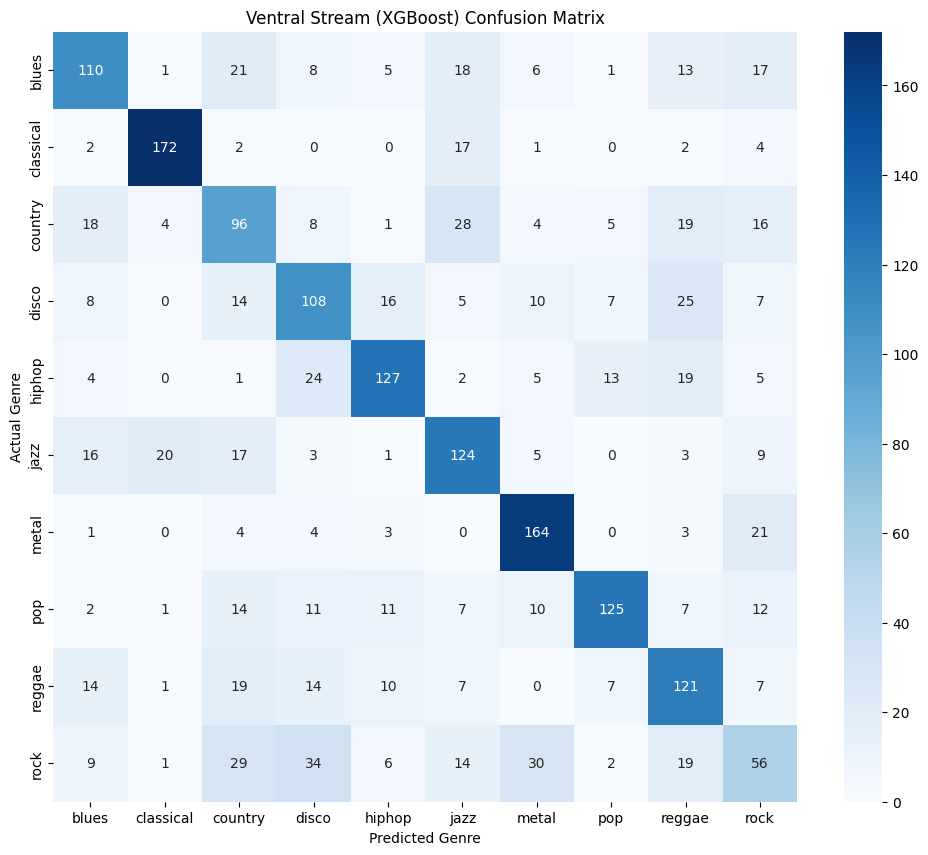

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- TODO: Generate the Classification Report ---
# HINT: This gives you Precision, Recall, and F1-Score.
# F1-Score is the "Gold Standard" for your thesis.
report = classification_report(y_test, y_pred, target_names=genre_names)
print("--- XGBoost Specialist Report ---")
print(report)

# --- TODO: Compute the Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

# --- TODO: Visualize with a Heatmap ---
# HINT: Use square=True and annot=True to make the numbers clear.
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=genre_names, 
    yticklabels=genre_names
)

plt.title('Ventral Stream (XGBoost) Confusion Matrix')
plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.show()

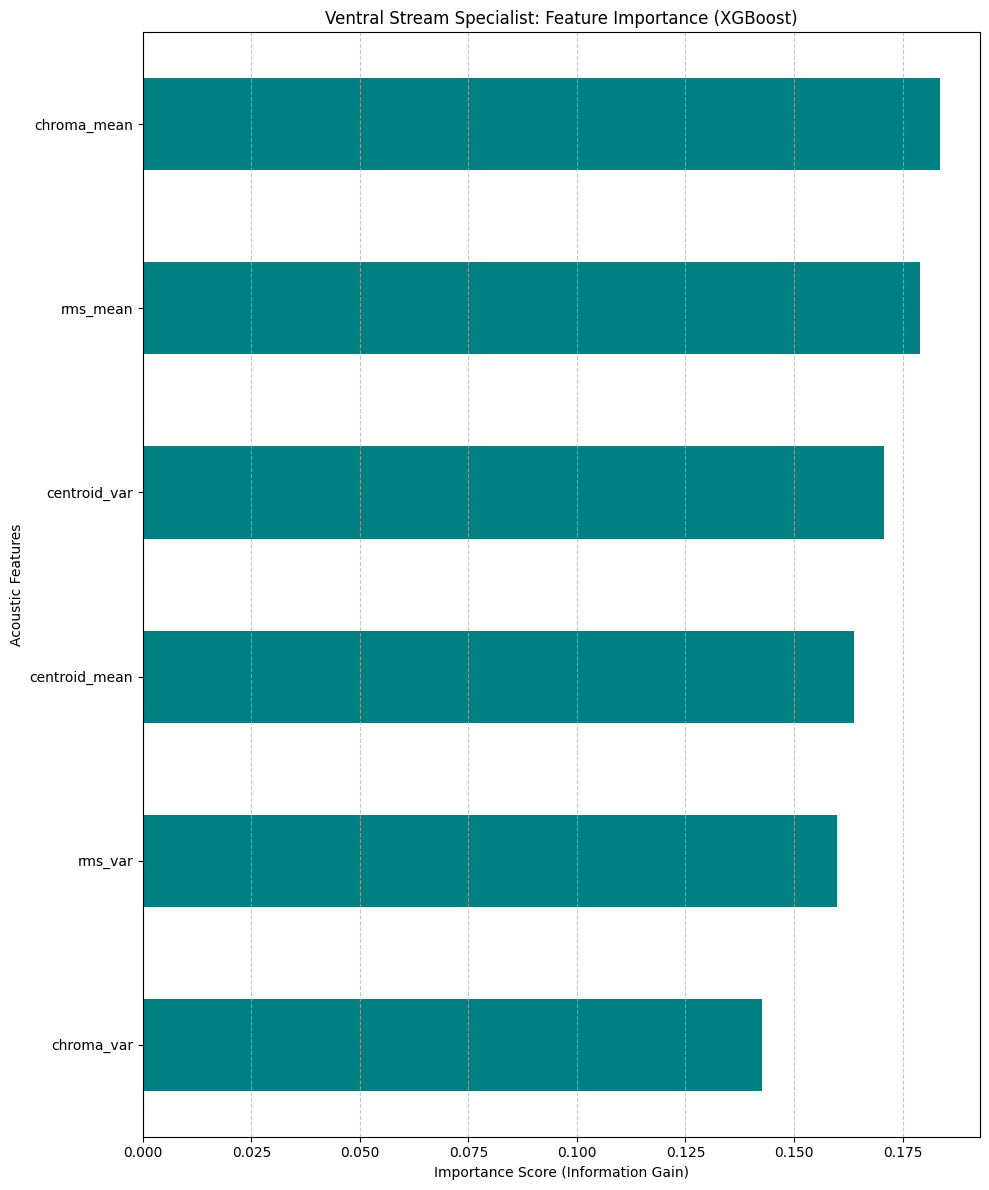

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

importances = model.feature_importances_
feature_names = X.columns

feat_import_series = pd.Series(importances, index=feature_names)
feat_import_series = feat_import_series.sort_values(ascending=True)

plt.figure(figsize=(10, 12))
feat_import_series.plot(kind='barh', color='teal')

plt.title("Ventral Stream Specialist: Feature Importance (XGBoost)")
plt.xlabel("Importance Score (Information Gain)")
plt.ylabel("Acoustic Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

save_path = os.path.join(os.getcwd(), 'feature_importance_xgb.png')
plt.savefig(save_path, dpi=300)
plt.show()